# Telco Customer Churn – Exploratory Data Analysis

This notebook explores the Telco Customer Churn dataset. The goal is to understand which customer and service characteristics are associated with churn (Yes/No), using data cleaning, feature engineering, exploratory data analysis, and basic statistical techniques.

In [2]:
# Import libraries and set global options
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Data Import and Dataset Description

We load the Telco Customer Churn CSV file into a pandas DataFrame, check basic structure, and describe the key variables such as demographics, services, billing information, and the churn flag.

In [3]:
# Load the Telco Customer Churn dataset
file_path = "Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

# Basic checks
df_shape = df.shape
df_head = df.head()
df_shape, df_head

((7043, 21),
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
 0  7590-VHVEG  Female              0     Yes         No       1           No   
 1  5575-GNVDE    Male              0      No         No      34          Yes   
 2  3668-QPYBK    Male              0      No         No       2          Yes   
 3  7795-CFOCW    Male              0      No         No      45           No   
 4  9237-HQITU  Female              0      No         No       2          Yes   
 
       MultipleLines InternetService OnlineSecurity OnlineBackup  \
 0  No phone service             DSL             No          Yes   
 1                No             DSL            Yes           No   
 2                No             DSL            Yes          Yes   
 3  No phone service             DSL            Yes           No   
 4                No     Fiber optic             No           No   
 
   DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
 0        

## 2. Deep Initial Profiling

We inspect data types, missing values, and basic statistics for numeric and categorical features. A custom summary function is used to provide a compact overview.

In [4]:
# Basic structural information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Numeric summary
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [6]:
# Simple frequency table for selected categorical features
categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "InternetService", "Contract",
    "PaperlessBilling", "PaymentMethod", "Churn"
]

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))


Value counts for gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Value counts for SeniorCitizen:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Value counts for Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Value counts for Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Value counts for PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Value counts for InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Value counts for Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Value counts for PaperlessBilling:
PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

Value counts for PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)   

In [7]:
# Custom summary function (UDF) for detailed overview
def detailed_summary(data: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame({
        "DataType": data.dtypes,
        "MissingValues": data.isna().sum(),
        "UniqueValues": data.nunique(),
        "Mean": data.select_dtypes(include=["number"]).mean(),
        "Median": data.select_dtypes(include=["number"]).median(),
        "StdDev": data.select_dtypes(include=["number"]).std(),
        "Mode": data.mode().iloc[0]
    })
    return summary

detailed_summary(df)

,DataType,MissingValues,UniqueValues,Mean,Median,StdDev,Mode
Churn,str,0,2,NaN,NaN,NaN,No
Contract,str,0,3,NaN,NaN,NaN,Month-to-month
Dependents,str,0,2,NaN,NaN,NaN,No
DeviceProtection,str,0,3,NaN,NaN,NaN,No
InternetService,str,0,3,NaN,NaN,NaN,Fiber optic
MonthlyCharges,float64,0,1585,64.761692,70.350,30.090047,20.05
MultipleLines,str,0,3,NaN,NaN,NaN,No
OnlineBackup,str,0,3,NaN,NaN,NaN,No
OnlineSecurity,str,0,3,NaN,NaN,NaN,No
PaperlessBilling,str,0,2,NaN,NaN,NaN,Yes


## 3. Advanced Data Cleaning

We handle missing or invalid values (especially in `TotalCharges`), check duplicates, and ensure appropriate data types. A list comprehension is used to collect service-related columns.

Convert TotalCharges to numeric and inspect problematic rows

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing_total = df[df["TotalCharges"].isna()]
missing_total.head(), missing_total.shape

(      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
 488   4472-LVYGI  Female              0     Yes        Yes       0   
 753   3115-CZMZD    Male              0      No        Yes       0   
 936   5709-LVOEQ  Female              0     Yes        Yes       0   
 1082  4367-NUYAO    Male              0     Yes        Yes       0   
 1340  1371-DWPAZ  Female              0     Yes        Yes       0   
 
      PhoneService     MultipleLines InternetService       OnlineSecurity  \
 488            No  No phone service             DSL                  Yes   
 753           Yes                No              No  No internet service   
 936           Yes                No             DSL                  Yes   
 1082          Yes               Yes              No  No internet service   
 1340           No  No phone service             DSL                  Yes   
 
              OnlineBackup     DeviceProtection          TechSupport  \
 488                    No          

##### Handle missing TotalCharges by dropping those few rows

In [9]:
df = df.dropna(subset=["TotalCharges"])
df.shape

(7032, 21)

##### Check for duplicate customer IDs

In [10]:
duplicate_ids = df["customerID"].duplicated().sum()
duplicate_ids

np.int64(0)

##### Ensure correct dtypes

In [11]:
df["SeniorCitizen"] = df["SeniorCitizen"].astype(int)
categorical_features = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod", "Churn"
]
for col in categorical_features:
    df[col] = df[col].astype("category")

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numeric_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


##### IQR-based outlier detector (UDF)

In [12]:
def detect_outliers_iqr(data: pd.Series) -> pd.Series:
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (data < lower) | (data > upper)

outliers_monthly = detect_outliers_iqr(df["MonthlyCharges"]).sum()
outliers_total = detect_outliers_iqr(df["TotalCharges"]).sum()
tenure = detect_outliers_iqr(df["tenure"]).sum()
outliers_monthly, outliers_total, tenure

(np.int64(0), np.int64(0), np.int64(0))

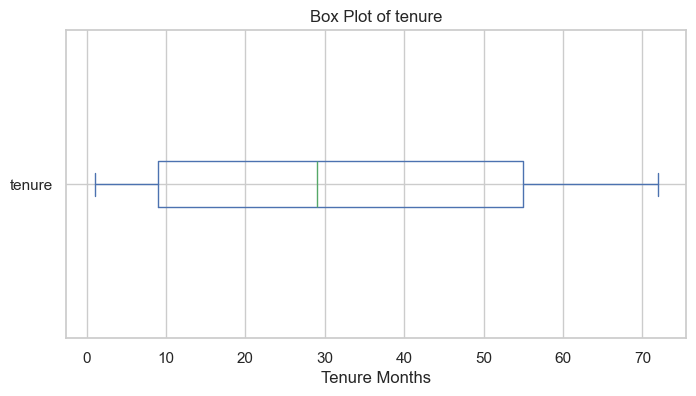

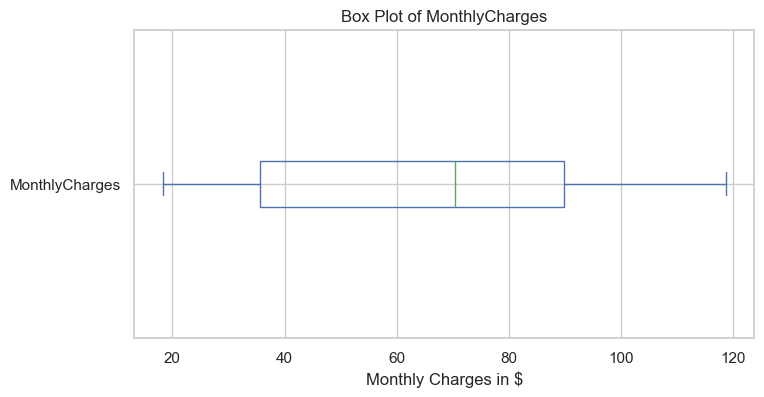

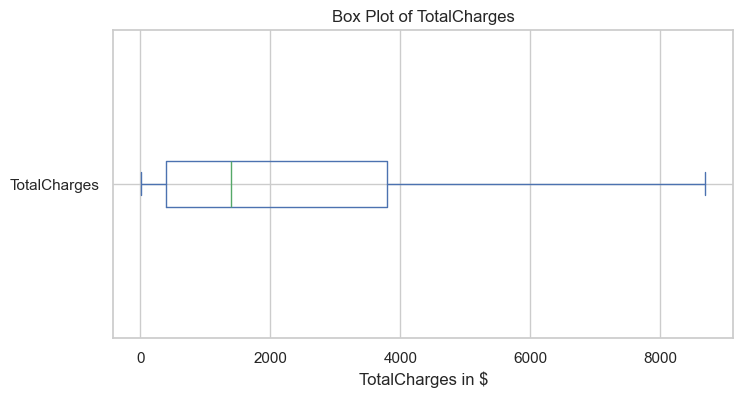

In [13]:
df[["tenure"]].plot(kind="box", vert=False, figsize=(8, 4))
plt.xlabel('Tenure Months')
plt.title("Box Plot of tenure")
plt.show()
df[["MonthlyCharges"]].plot(kind="box", vert=False, figsize=(8, 4))
plt.title("Box Plot of MonthlyCharges")
plt.xlabel('Monthly Charges in $')
plt.show()
df[["TotalCharges"]].plot(kind="box", vert=False, figsize=(8, 4))
plt.title("Box Plot of TotalCharges")
plt.xlabel("TotalCharges in $")
plt.show()

## 4. Feature Engineering (Lambda, UDF, and New Features)

We create new features that may help explain churn, including numeric flags and grouped categories. This section explicitly demonstrates lambda functions and user-defined functions.

In [14]:
# Lambda example: create numeric churn flag
df["ChurnFlag"] = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

# Tenure group using a UDF function
def tenure_to_group(tenure: int) -> str:
    if tenure <= 12:
        return "New"
    elif tenure <= 24:
        return "Recent"
    elif tenure <= 48:
        return "Established"
    else:
        return "Loyal"

df["TenureGroup"] = df["tenure"].apply(tenure_to_group)
df["TenureGroup"] = df["TenureGroup"].astype("category")
df["ChurnFlag"].value_counts(), df["TenureGroup"].value_counts()

(ChurnFlag
 0    5163
 1    1869
 Name: count, dtype: int64,
 TenureGroup
 Loyal          2239
 New            2175
 Established    1594
 Recent         1024
 Name: count, dtype: int64)

##### List comprehension example: collect all service-related columns

In [15]:
# UDF example: count number of subscribed services per customer
service_cols = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
def count_services(row: pd.Series) -> int:
    return sum(1 for col in service_cols if row[col] == "Yes")


df["ServiceCount"] = df.apply(count_services, axis=1)

# Additional feature: family flag (has partner or dependents)
df["FamilyFlag"] = np.where((df["Partner"] == "Yes") | (df["Dependents"] == "Yes"), 1, 0)
df[["ServiceCount"]].describe()

,ServiceCount
count,7032.000000
mean,3.363339
std,2.062067
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,8.000000


## 5. Descriptive Statistics

We summarize key numeric and categorical variables to understand typical customer tenure, charges, and churn distribution.

In [16]:
# Numeric descriptive statistics
df[["tenure", "MonthlyCharges", "TotalCharges", "ServiceCount"]].describe()

,tenure,MonthlyCharges,TotalCharges,ServiceCount
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,3.363339
std,24.545260,30.085974,2266.771362,2.062067
min,1.000000,18.250000,18.800000,0.000000
25%,9.000000,35.587500,401.450000,1.000000
50%,29.000000,70.350000,1397.475000,3.000000
75%,55.000000,89.862500,3794.737500,5.000000
max,72.000000,118.750000,8684.800000,8.000000


In [17]:
# Categorical descriptive statistics for selected features
cat_summary_cols = ["Churn", "Contract", "InternetService", "PaymentMethod", "TenureGroup"]

for col in cat_summary_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(normalize=True).round(3))


=== Churn ===
Churn
No     0.734
Yes    0.266
Name: proportion, dtype: float64

=== Contract ===
Contract
Month-to-month    0.551
Two year          0.240
One year          0.209
Name: proportion, dtype: float64

=== InternetService ===
InternetService
Fiber optic    0.440
DSL            0.344
No             0.216
Name: proportion, dtype: float64

=== PaymentMethod ===
PaymentMethod
Electronic check             0.336
Mailed check                 0.228
Bank transfer (automatic)    0.219
Credit card (automatic)      0.216
Name: proportion, dtype: float64

=== TenureGroup ===
TenureGroup
Loyal          0.318
New            0.309
Established    0.227
Recent         0.146
Name: proportion, dtype: float64


## 6. Univariate Visualizations – Distributions

We visualize the distributions of tenure, monthly charges, total charges, and churn-related categorical features.

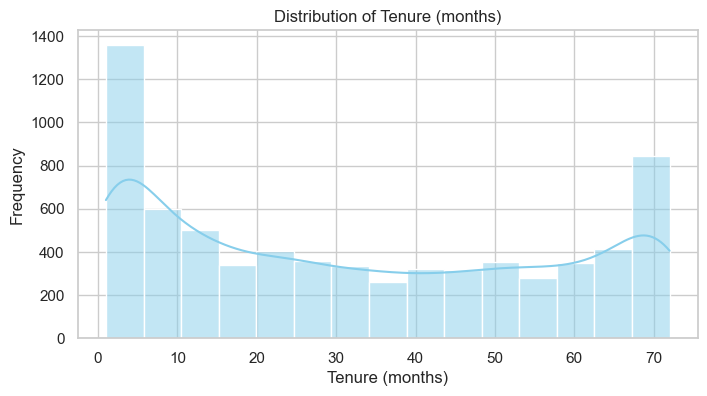

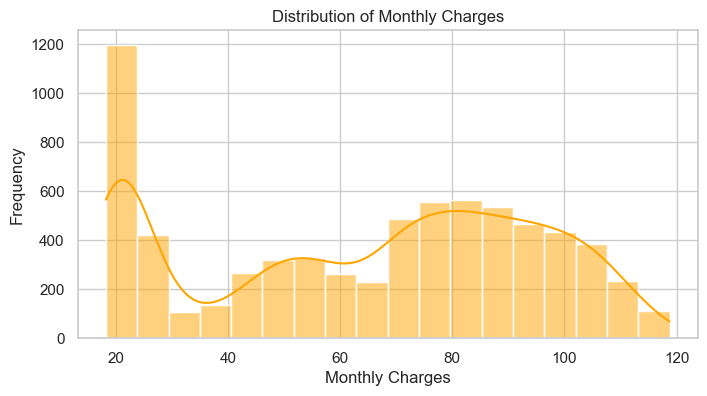

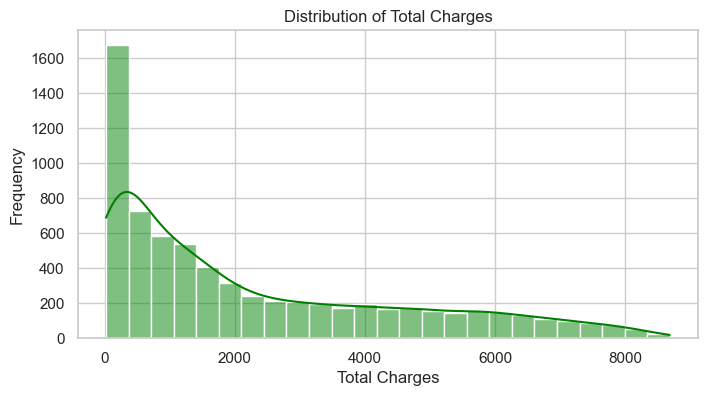

In [18]:
plt.figure(figsize=(8, 4))
sns.histplot(df["tenure"], kde=True, color="skyblue")
plt.title("Distribution of Tenure (months)")
plt.xlabel("Tenure (months)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df["MonthlyCharges"], kde=True, color="orange")
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df["TotalCharges"], kde=True, color="green")
plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")
plt.show()


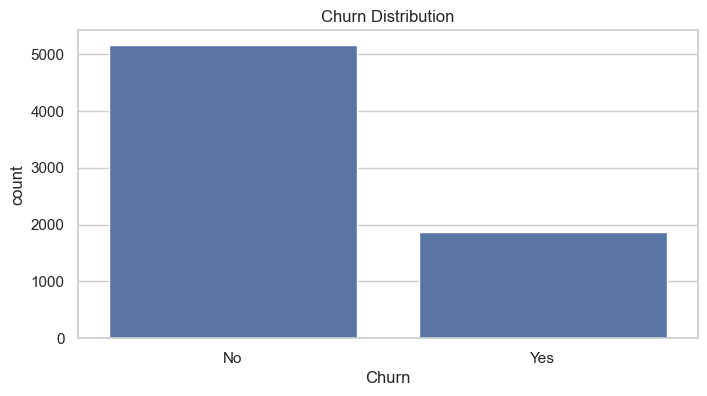

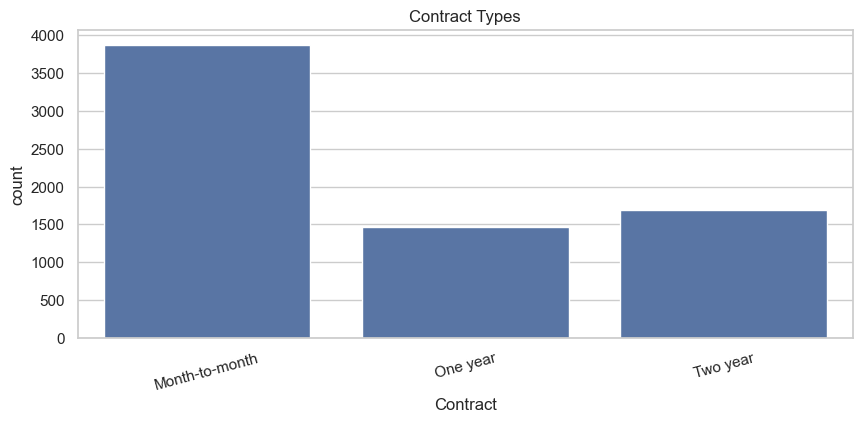

In [19]:
plt.figure(figsize=(8, 4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

plt.figure(figsize=(10, 4))
sns.countplot(x="Contract", data=df, order=["Month-to-month", "One year", "Two year"])
plt.title("Contract Types")
plt.xticks(rotation=15)
plt.show()

## 7. Bivariate Analysis – Churn vs Key Features

We compare churn across different customer segments and examine how numeric variables differ between churned and non-churned customers.

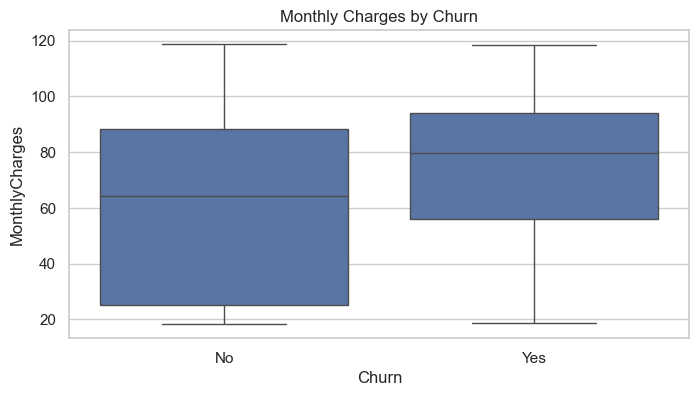

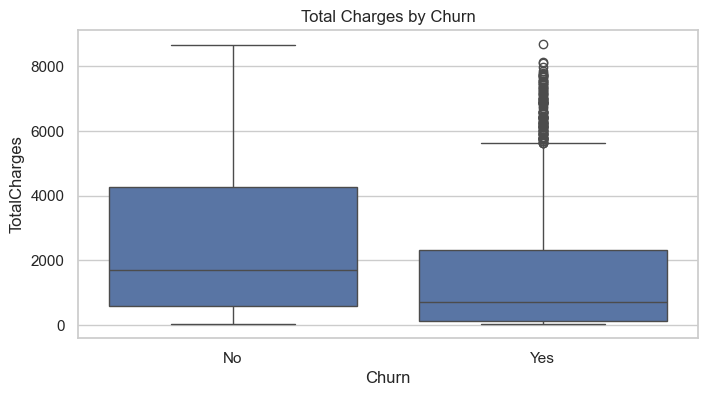

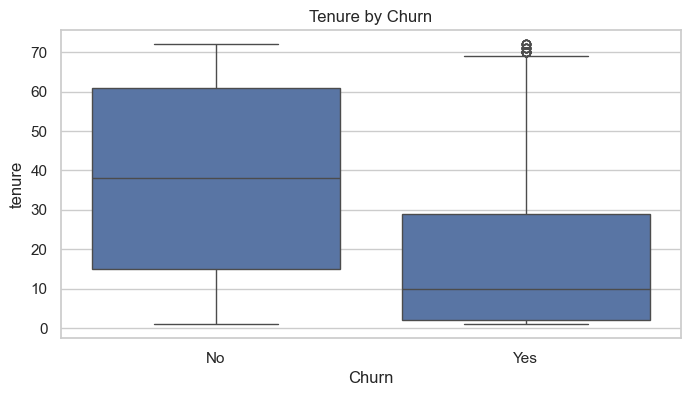

In [20]:
# Numeric variables vs churn (violin plots)
plt.figure(figsize=(8, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("Total Charges by Churn")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure by Churn")
plt.show()


In [21]:
# Categorical features vs churn (proportions)
def churn_rate_by_category(column: str) -> pd.DataFrame:
    ct = pd.crosstab(df[column], df["Churn"], normalize="index")
    return ct

churn_by_contract = churn_rate_by_category("Contract")
churn_by_tenure_group = churn_rate_by_category("TenureGroup")
churn_by_contract, churn_by_tenure_group

(Churn                 No       Yes
 Contract                          
 Month-to-month  0.572903  0.427097
 One year        0.887228  0.112772
 Two year        0.971513  0.028487,
 Churn              No       Yes
 TenureGroup                    
 Established  0.796110  0.203890
 Loyal        0.904868  0.095132
 New          0.523218  0.476782
 Recent       0.712891  0.287109)

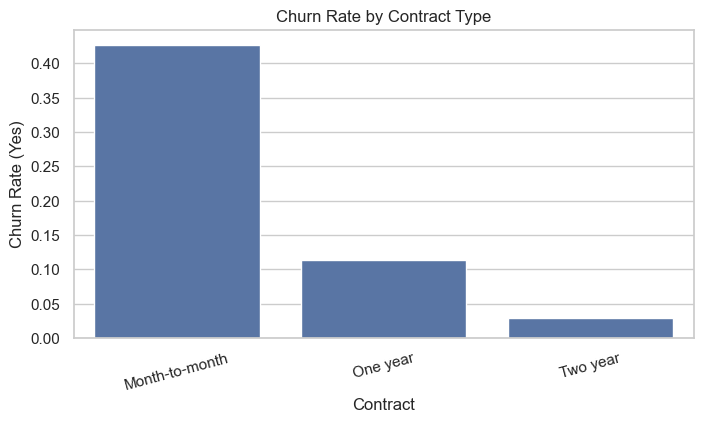

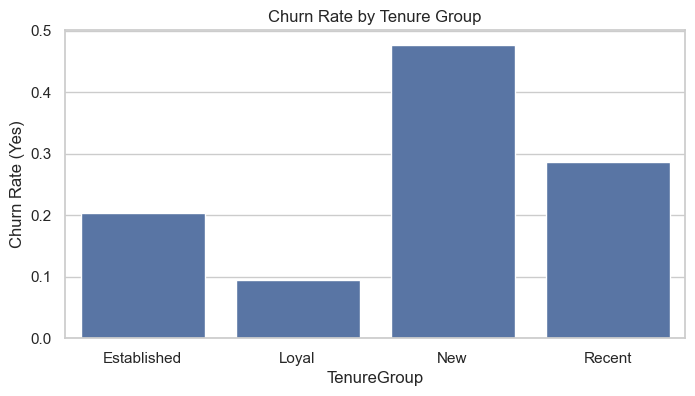

In [22]:
plt.figure(figsize=(8, 4))
sns.barplot(x=churn_by_contract.index, y=churn_by_contract["Yes"].values)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (Yes)")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x=churn_by_tenure_group.index, y=churn_by_tenure_group["Yes"].values)
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate (Yes)")
plt.show()

## 8. Correlation and Multivariate Patterns

We compute correlations among numeric features, including the churn flag, and visualize them using a heatmap to identify important relationships.

In [23]:
numeric_for_corr = df[["tenure", "MonthlyCharges", "TotalCharges", "ServiceCount", "FamilyFlag", "ChurnFlag"]]
corr_matrix = numeric_for_corr.corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges,ServiceCount,FamilyFlag,ChurnFlag
tenure,1.000000,0.246862,0.825880,0.524441,0.347367,-0.354049
MonthlyCharges,0.246862,1.000000,0.651065,0.802368,0.056393,0.192858
TotalCharges,0.825880,0.651065,1.000000,0.796885,0.277450,-0.199484
ServiceCount,0.524441,0.802368,0.796885,1.000000,0.186601,-0.067459
FamilyFlag,0.347367,0.056393,0.277450,0.186601,1.000000,-0.162113
ChurnFlag,-0.354049,0.192858,-0.199484,-0.067459,-0.162113,1.000000


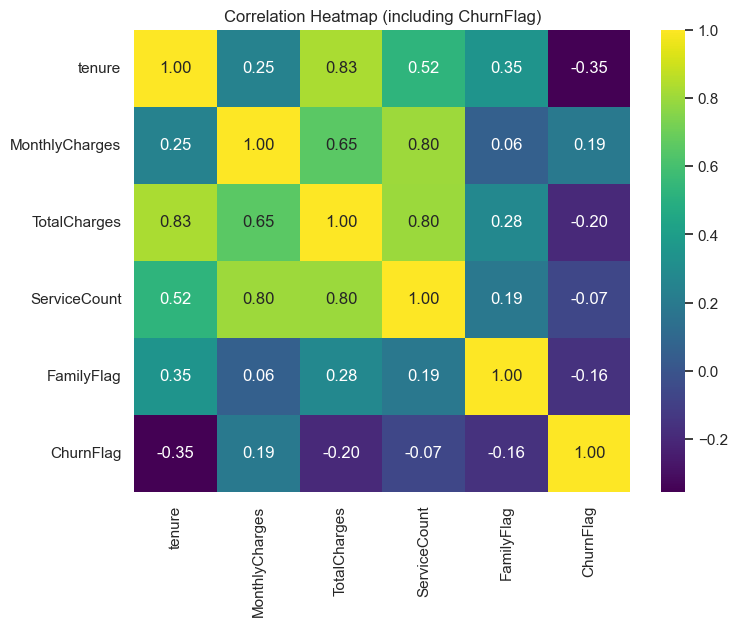

In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap (including ChurnFlag)")
plt.show()

## 9. Group Analysis / Segmentation

We aggregate churn rate, tenure, and charges across key customer segments such as contract type, internet service, tenure group, and service count.

In [25]:
df["ChurnFlag"] = pd.to_numeric(df["ChurnFlag"], errors="coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")
df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")

group_contract = df.groupby("Contract").agg({
    "ChurnFlag": "mean",
    "MonthlyCharges": "mean",
    "tenure": "mean"
}).rename(columns={"ChurnFlag": "ChurnRate"})

group_contract

,ChurnRate,MonthlyCharges,tenure
Contract,,,
Month-to-month,0.427097,66.398490,18.036645
One year,0.112772,65.079416,42.073370
Two year,0.028487,60.872374,57.071810


In [26]:
# Multi-level groupby: InternetService and Contract
group_internet_contract = df.groupby(["InternetService", "Contract"]).agg({
    "ChurnFlag": "mean",
    "MonthlyCharges": "mean"
}).rename(columns={"ChurnFlag": "ChurnRate"})
group_internet_contract

ChurnRate  MonthlyCharges
InternetService Contract                                 
DSL             Month-to-month   0.322159       50.219501
                One year         0.092982       61.396754
                Two year         0.019262       70.507303
Fiber optic     Month-to-month   0.546053       87.021194
                One year         0.192950       98.779499
                Two year         0.072261      104.571445
No              Month-to-month   0.188931       20.409542
                One year         0.024793       20.822590
                Two year         0.007899       21.773697

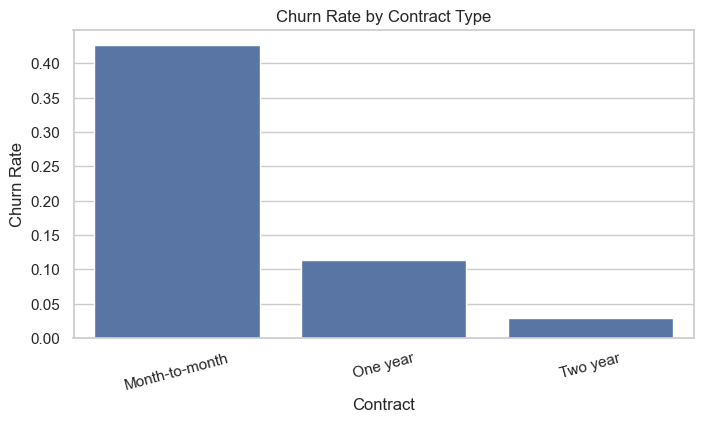

In [27]:
plt.figure(figsize=(8, 4))
sns.barplot(x=group_contract.index, y=group_contract["ChurnRate"].values)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=15)
plt.show()

In [29]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag,TenureGroup,ServiceCount,FamilyFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,New,1,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,Established,3,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,New,3,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,Established,3,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,New,1,0


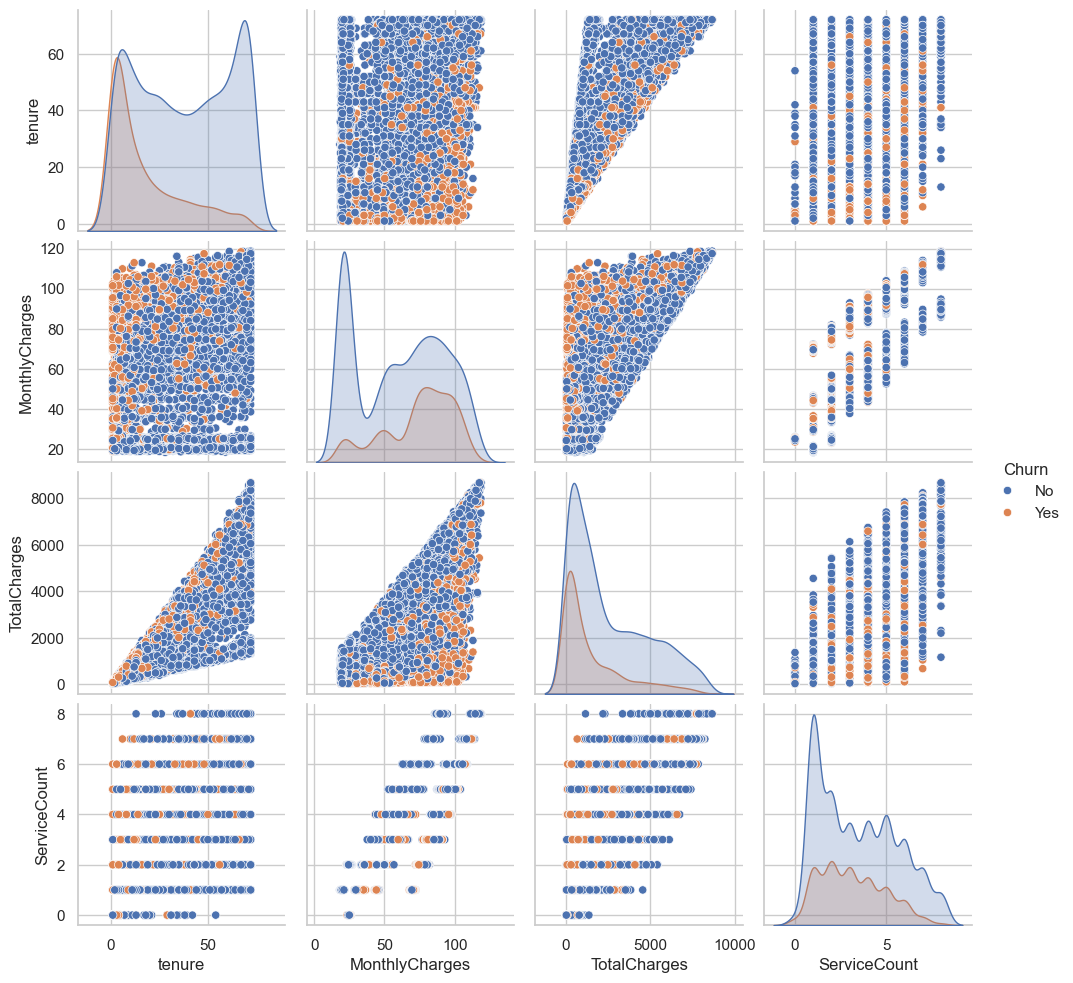

In [31]:
sns.pairplot(df[["tenure", "MonthlyCharges", "TotalCharges","ServiceCount", "Churn"]], hue="Churn")
plt.show()


## 10. Insights and Conclusions

### Key Insights
- **Contract type is the strongest churn indicator** 
    - Customers on **month-to-month contracts** show the highest churn
    - Customers on **one-year** and **two-year contracts** are more likely to stay.
- **Tenure is negatively related to churn.** 
    - Customers who churn generally have much shorter tenure, suggesting that newer customers are at higher risk.
- **Monthly charges matter.** 
    - Customers with higher monthly charges tend to churn more often than customers with lower monthly charges.
- **Internet service type shows clear segment differences.** 
    - Grouped analysis suggests that **fiber-optic customers on month-to-month contracts** are among the highest-risk groups.
- **Payment method is also associated with churn.** 
    - Customers using **electronic check** tend to churn more than customers using automatic payment methods.

### Conclusion
- The most important churn-related features in this notebook are **Contract, tenure, MonthlyCharges, InternetService, and PaymentMethod**.
- The results are supported by **summary statistics, visualizations, correlations, and grouped comparisons**.
- These findings should be interpreted as **associations**, not direct causal proof.

### Possible Next Steps
- Build a predictive churn model using the cleaned and engineered features.
- Perform hypothesis testing or model-based validation to confirm which patterns are statistically robust.
- Explore additional business variables such as support interactions, complaints, or satisfaction scores if available.
- Use the identified high-risk segments to design retention strategies for further testing.
